# 02. Preprocesamiento de consumo eléctrico

Este cuaderno descarga desde UCI el conjunto Individual Household Electric Power Consumption, carga `household_power_consumption.txt`, trata valores ausentes y prepara una tabla horaria para regresión con `Global_active_power` como variable respuesta.


In [1]:
import io
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
import requests

from pathlib import Path


## 1. Descarga y carga del dataset


In [2]:
POWER_URL = "https://archive.ics.uci.edu/static/public/235/individual%2Bhousehold%2Belectric%2Bpower%2Bconsumption.zip"

respuesta = requests.get(POWER_URL, timeout=300)
respuesta.raise_for_status()

with zipfile.ZipFile(io.BytesIO(respuesta.content)) as archivo_zip:
    archivos_zip = archivo_zip.namelist()
    with archivo_zip.open("household_power_consumption.txt") as archivo:
        consumo = pd.read_csv(
            archivo,
            sep=";",
            na_values="?",
            low_memory=False,
        )

resumen_carga = pd.DataFrame([{
    "dataset": "Individual Household Electric Power Consumption",
    "filas": consumo.shape[0],
    "columnas": consumo.shape[1],
    "archivo_utilizado": "household_power_consumption.txt",
}])

display(resumen_carga)
consumo.head()


,dataset,filas,columnas,archivo_utilizado
0,Individual Household Electric Power Consumption,2075259,9,household_power_consumption.txt


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 2. Fechas, tipos y valores ausentes


In [3]:
consumo["datetime"] = pd.to_datetime(
    consumo["Date"] + " " + consumo["Time"],
    dayfirst=True,
    errors="coerce",
)

for columna in consumo.columns:
    if columna not in ["Date", "Time", "datetime"]:
        consumo[columna] = pd.to_numeric(consumo[columna], errors="coerce")

valores_ausentes = consumo.isna().sum().rename_axis("variable").reset_index(name="n_missing")
valores_ausentes["porcentaje_missing"] = valores_ausentes["n_missing"] / len(consumo)
display(valores_ausentes)

periodo = pd.DataFrame([{
    "fecha_inicio": consumo["datetime"].min(),
    "fecha_fin": consumo["datetime"].max(),
    "n_registros": len(consumo),
    "n_columnas": consumo.shape[1],
}])
display(periodo)


,variable,n_missing,porcentaje_missing
0,Date,0,0.000000
1,Time,0,0.000000
2,Global_active_power,25979,0.012518
3,Global_reactive_power,25979,0.012518
4,Voltage,25979,0.012518
5,Global_intensity,25979,0.012518
6,Sub_metering_1,25979,0.012518
7,Sub_metering_2,25979,0.012518
8,Sub_metering_3,25979,0.012518
9,datetime,0,0.000000


,fecha_inicio,fecha_fin,n_registros,n_columnas
0,2006-12-16 17:24:00,2010-11-26 21:02:00,2075259,10


## 3. Agregación horaria


In [4]:
objetivo = "Global_active_power"

consumo_horario = (
    consumo.dropna(subset=["datetime"])
    .set_index("datetime")
    .drop(columns=["Date", "Time"])
    .resample("h")
    .mean()
)

consumo_horario = consumo_horario.dropna(subset=[objetivo])
consumo_horario["hora"] = consumo_horario.index.hour
consumo_horario["dia_semana"] = consumo_horario.index.dayofweek
consumo_horario["mes"] = consumo_horario.index.month
consumo_horario["dia"] = consumo_horario.index.day
consumo_horario["fin_de_semana"] = (consumo_horario["dia_semana"] >= 5).astype(int)

resumen_horario = pd.DataFrame([{
    "filas": consumo_horario.shape[0],
    "columnas": consumo_horario.shape[1],
    "fecha_inicio": consumo_horario.index.min(),
    "fecha_fin": consumo_horario.index.max(),
}])

display(resumen_horario)
display(consumo_horario.head())
consumo_horario.describe().T


,filas,columnas,fecha_inicio,fecha_fin
0,34168,12,2006-12-16 17:00:00,2010-11-26 21:00:00


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,day,is_weekend
datetime,,,,,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17,5,12,16,1
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18,5,12,16,1
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19,5,12,16,1
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20,5,12,16,1
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21,5,12,16,1


,count,mean,std,min,25%,50%,75%,max
Global_active_power,34168.0,1.091728,0.897619,0.124000,0.341925,0.802850,1.579342,6.560533
Global_reactive_power,34168.0,0.123727,0.066851,0.000000,0.078000,0.106917,0.149433,0.774333
Voltage,34168.0,240.839393,3.001093,225.834500,239.180667,240.977833,242.695000,251.902000
Global_intensity,34168.0,4.628238,3.757797,0.503333,1.513333,3.423333,6.606667,28.383333
Sub_metering_1,34168.0,1.121631,3.538046,0.000000,0.000000,0.000000,0.000000,48.366667
Sub_metering_2,34168.0,1.298566,4.192874,0.000000,0.000000,0.333333,0.650000,46.433333
Sub_metering_3,34168.0,6.458882,7.351219,0.000000,0.650000,1.650000,14.216667,21.550000
hour,34168.0,11.504888,6.925248,0.000000,6.000000,12.000000,18.000000,23.000000
day_of_week,34168.0,2.989522,1.997732,0.000000,1.000000,3.000000,5.000000,6.000000
month,34168.0,6.454724,3.423204,1.000000,3.000000,6.000000,9.000000,12.000000


## 4. Visualización de la variable respuesta


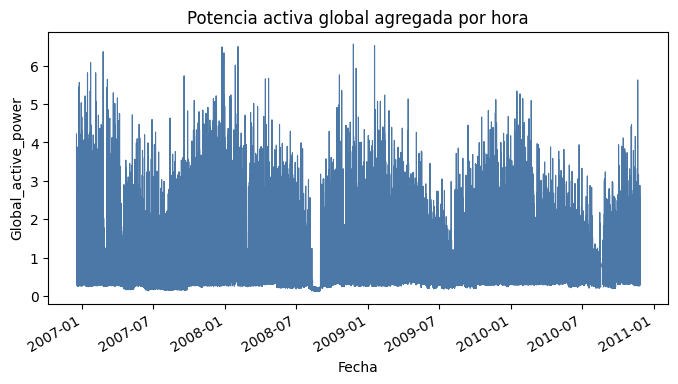

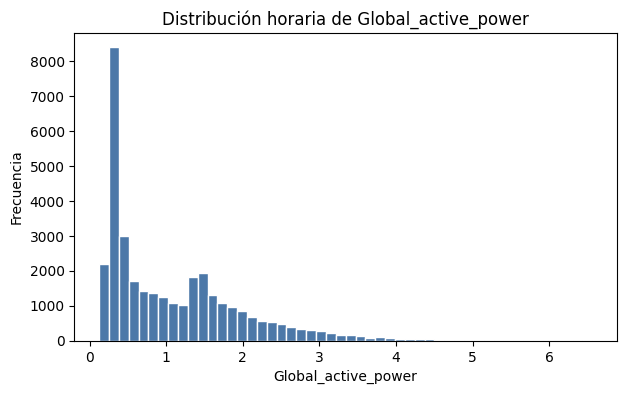

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
consumo_horario[objetivo].plot(ax=ax, color="#4c78a8", linewidth=0.8)
ax.set_title("Potencia activa global agregada por hora")
ax.set_xlabel("Fecha")
ax.set_ylabel("Global_active_power")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(consumo_horario[objetivo].dropna(), bins=50, color="#4c78a8", edgecolor="white")
ax.set_title("Distribución horaria de Global_active_power")
ax.set_xlabel("Global_active_power")
ax.set_ylabel("Frecuencia")
plt.show()


## 5. Separación temporal y guardado


In [6]:
consumo_modelo = consumo_horario.reset_index()
consumo_modelo["datetime"] = consumo_modelo["datetime"].astype(str)

punto_corte = int(len(consumo_modelo) * (1 - 0.20))
consumo_train = consumo_modelo.iloc[:punto_corte].copy()
consumo_test = consumo_modelo.iloc[punto_corte:].copy()

Path("data/processed/serie_computacional").mkdir(parents=True, exist_ok=True)
Path("reports/tables/serie_computacional").mkdir(parents=True, exist_ok=True)
Path("reports/figures/serie_computacional").mkdir(parents=True, exist_ok=True)

consumo_train.to_csv("data/processed/serie_computacional/power_train_hourly.csv", index=False)
consumo_test.to_csv("data/processed/serie_computacional/power_test_hourly.csv", index=False)

valores_ausentes.to_csv("reports/tables/serie_computacional/power_valores_ausentes.csv", index=False)
periodo.to_csv("reports/tables/serie_computacional/power_periodo_original.csv", index=False)
consumo_horario.describe().T.to_csv("reports/tables/serie_computacional/power_resumen_horario.csv")

resumen_split = pd.DataFrame([
    {"split": "train", "filas": len(consumo_train), "fecha_inicio": consumo_train["datetime"].min(), "fecha_fin": consumo_train["datetime"].max()},
    {"split": "test", "filas": len(consumo_test), "fecha_inicio": consumo_test["datetime"].min(), "fecha_fin": consumo_test["datetime"].max()},
])
resumen_split.to_csv("reports/tables/serie_computacional/power_resumen_split_temporal.csv", index=False)

resumen_split


,split,filas,fecha_inicio,fecha_fin
0,train,27334,2006-12-16 17:00:00,2010-02-05 04:00:00
1,test,6834,2010-02-05 05:00:00,2010-11-26 21:00:00
